<a href="https://colab.research.google.com/github/AneDesiree/mlp-breast-cancer-classification/blob/main/breast_cancer_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Breast Cancer Classification using Multi-Layer Perceptron (MLP)**\
**Author: Aiane Desirée dos Santos Bastos**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score, make_scorer, precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets
df = pd.concat([X, y], axis=1)

**Pré-processamento de dados**

In [ ]:
# Excluindo as linhas com valores NaN
df = df.dropna()

In [ ]:
# Excluindo as linhas duplicadas, mantendo a primeira ocorrência
df_clean = df.drop_duplicates()

In [ ]:
X = df_clean.drop(columns = ['Class'])
y = df_clean['Class']

In [ ]:
counts = y.value_counts()
percent = y.value_counts(normalize=True) * 100
res = pd.DataFrame({'Quantidade': counts, 'Porcentagem (%)': percent})
display(res)

,Quantidade,Porcentagem (%)
Class,,
4,236,52.561247
2,213,47.438753


In [ ]:
# Dividindo os dados entre treinamento e teste com proporção de 30% para o conjunto de teste e 70% para o de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Escalonando dos dados
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**MLP:**


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
resultados = []
for n_neuronios in range(6, 16):
    print(f"Testando {n_neuronios} neurônios na camada oculta")
    mlp_teste = MLPClassifier(hidden_layer_sizes=(n_neuronios,), max_iter=2000, random_state=0)

    # Validação cruzada
    scores = cross_val_score(mlp_teste, X_train, y_train, cv=cv, scoring='accuracy')
    media_acuracia = np.mean(scores)
    resultados.append((n_neuronios, media_acuracia))
    print(f"Acurácia média com validação cruzada: {media_acuracia:.2f}\n")

melhor_configuracao = max(resultados, key=lambda x: x[1])
print(f"Melhor número de neurônios: {melhor_configuracao[0]} com acurácia de {melhor_configuracao[1]:.2f}")

Testando 6 neurônios na camada oculta
Acurácia média com validação cruzada: 0.95

Testando 7 neurônios na camada oculta
Acurácia média com validação cruzada: 0.94

Testando 8 neurônios na camada oculta
Acurácia média com validação cruzada: 0.93

Testando 9 neurônios na camada oculta
Acurácia média com validação cruzada: 0.94

Testando 10 neurônios na camada oculta
Acurácia média com validação cruzada: 0.95

Testando 11 neurônios na camada oculta
Acurácia média com validação cruzada: 0.95

Testando 12 neurônios na camada oculta
Acurácia média com validação cruzada: 0.96

Testando 13 neurônios na camada oculta
Acurácia média com validação cruzada: 0.94

Testando 14 neurônios na camada oculta
Acurácia média com validação cruzada: 0.95

Testando 15 neurônios na camada oculta
Acurácia média com validação cruzada: 0.94

Melhor número de neurônios: 12 com acurácia de 0.96


In [ ]:
# Treinando o modelo com o melhor número de neurônios
mlp = MLPClassifier(hidden_layer_sizes=(melhor_configuracao[0],), max_iter=500, random_state=0)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print('----------------------------------------------------')
print(f"Acurácia no conjunto de teste: {accuracy:.2f}")


Relatório de Classificação:
              precision    recall  f1-score   support

           2       0.96      0.97      0.96        68
           4       0.97      0.96      0.96        67

    accuracy                           0.96       135
   macro avg       0.96      0.96      0.96       135
weighted avg       0.96      0.96      0.96       135

----------------------------------------------------
Acurácia no conjunto de teste: 0.96


A acurácia média foi de 0.96, indicando que o modelo acertou 96% das predições no conjunto de teste. Esse valor indica que o modelo está bem ajustado, é consistente em diferentes amostras de dados e que não há sinais significativos de overfitting ou underfitting.

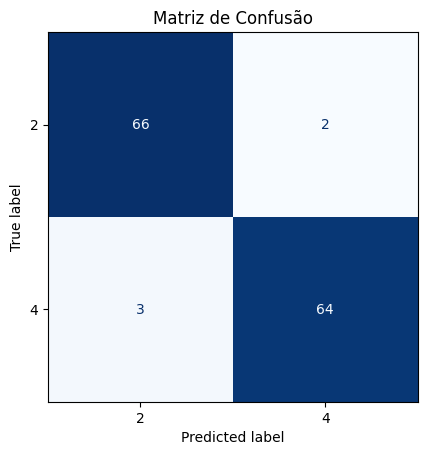

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=mlp.classes_).plot(cmap='Blues', colorbar=False)
plt.title("Matriz de Confusão")
plt.show()

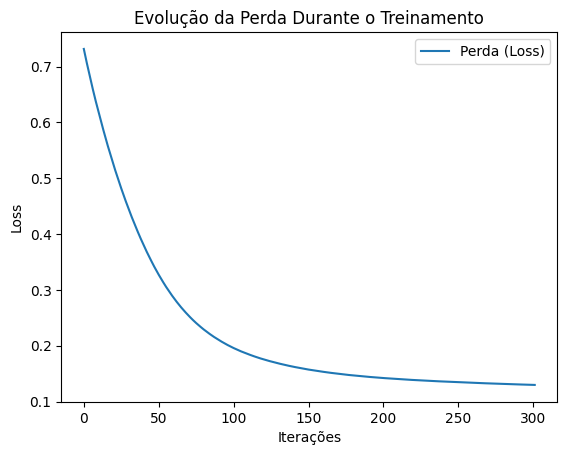

In [ ]:
plt.plot(mlp.loss_curve_, label="Perda (Loss)")
plt.title("Evolução da Perda Durante o Treinamento")
plt.xlabel("Iterações")
plt.ylabel("Loss")
plt.grid(False)
plt.legend()
plt.show()

Inicialmente, a perda é elevada porque o modelo começa com pesos aleatórios ou valores padrão, resultando em previsões distantes dos valores reais. Nas primeiras épocas, observa-se uma rápida redução na perda, indicando que o modelo está captando padrões relevantes nos dados e ajustando seus parâmetros para minimizar o erro. Com o passar das épocas, a taxa de redução da perda diminui gradualmente, sugerindo que o modelo está se aproximando de uma solução ótima e os ajustes nos pesos tornam-se menos significativos. Ao final, a curva de perda estabiliza-se em torno de 0.1, indicando que o modelo convergiu e alcançou sua melhor performance para a configuração de hiperparâmetros utilizada.

**Curva ROC:**


In [ ]:
# k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia do k-NN: {accuracy_knn:.2f}")

Acurácia do k-NN: 0.96


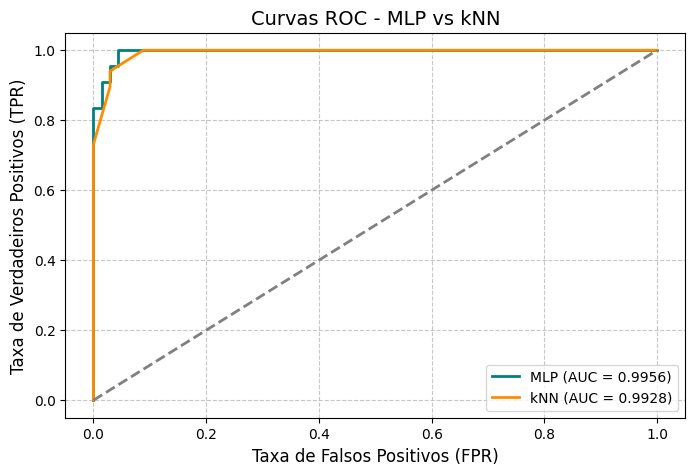

In [ ]:
y_probs_mlp = mlp.predict_proba(X_test)[:, 1]
y_probs_knn = knn.predict_proba(X_test)[:, 1]

# Curvas ROC para MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_probs_mlp, pos_label=4)
roc_auc_mlp = roc_auc_score(y_test, y_probs_mlp)

# Curvas ROC para kNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn, pos_label=4)
roc_auc_knn = roc_auc_score(y_test, y_probs_knn)

plt.figure(figsize=(8, 5))
plt.plot(fpr_mlp, tpr_mlp, color='teal', lw=2, label=f'MLP (AUC = {roc_auc_mlp:.4f})')
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label=f'kNN (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Curvas ROC - MLP vs kNN', fontsize=14)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Ambas as curvas estão muito próximas do canto superior esquerdo, o que indica que ambos os modelos têm um excelente desempenho. O MLP apresenta um valor de AUC = 0.9956, enquanto o k-NN tem um valor de AUC = 0.9928. Ambos os valores são altos, indicando que os modelos têm uma capacidade de discriminação quase perfeita entre as classes positiva e negativa.